In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
import sys

a  = -10
b = 10
epsilon = sys.float_info.epsilon
print(epsilon)

2.220446049250313e-16


In [29]:
p = [1, -2, -18, -32, -23, -6]

def f(x):
    return sum(p[i]*x**(5-i) for i in range(0, 6, 1))


roots = np.roots(p)
roots_real_part = [root.real for root in roots]
roots_imag_part = [root.imag for root in roots]

print("Корни:")
for i in range(len(roots)):
    print(f"{roots_real_part[i]:+.16f}{roots_imag_part[i]:+.16f}j")



Корни:
+5.9999999999999964+0.0000000000000000j
-1.0001096100017757+0.0001096192912350j
-1.0001096100017757-0.0001096192912350j
-0.9998903899982263+0.0001096007110953j
-0.9998903899982263-0.0001096007110953j


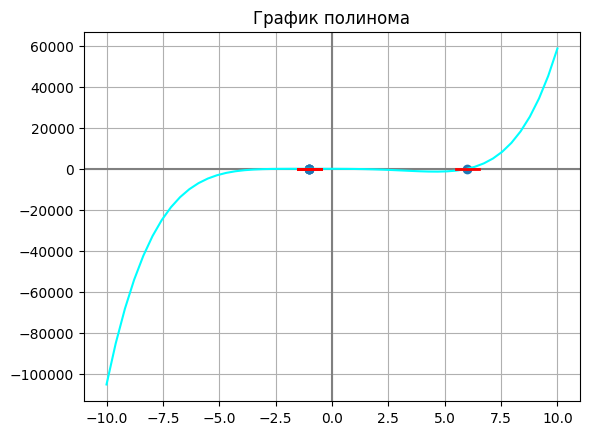

In [30]:

x = np.linspace(a, b)
y = f(x)

def draw_functioin(x, y):

    plt.grid()

    plt.axvline(x=0, color="gray")
    plt.axhline(y=0, color="gray")

    plt.plot(x, y, color="cyan")
    plt.scatter(roots_real_part, roots_imag_part)
    eps = 0.5

    for root in roots_real_part:

        xr = [root-eps, root+eps]
        yr = [0, 0]

        plt.plot(xr, yr, color="red", linewidth=2)
    plt.title("График полинома")
    plt.show()


draw_functioin(x, y)

In [31]:
def dihotomy(a, b, epsilon):
    if f(a) * f(b) > 0:
        print(f"Нет гарантии корня на [{a}, {b}]")
        return [None, 0]
    
    count = 0
    while (b - a) > epsilon:
        c = (a + b) / 2
        count += 1
        
        if abs(f(c)) < epsilon:
            return [c, count]
        
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
            
    return [(a + b) / 2, count]

dihotomy_root, count = dihotomy(a, b, epsilon)
print("Корень, найденный методом дихотомии:", dihotomy_root)
print("Реальное количество итераций:", count)
print("Теоретическое количество итераций:", math.modf(math.log((b-a)/epsilon, 2))[1] + 1)

Корень, найденный методом дихотомии: 6.0
Реальное количество итераций: 54
Теоретическое количество итераций: 57.0


In [32]:
def f(x): return x**5 - 2*x**4 - 18*x**3 - 32*x**2 - 23*x - 6
def df(x): return 5*x**4 - 8*x**3 - 54*x**2 - 64*x - 23

def newton(x):
    x_prev=0
    count=0
    while abs(x - x_prev) > epsilon:
        x_prev, x = x, x - f(x)/df(x)
        count += 1
    return (x, count)

res = newton(7)
print(f"Корни с помощью метода Ньютона: {res[0]}")
print(f"Количество итераций:", res[1])


Корни с помощью метода Ньютона: 6.0
Количество итераций: 7


In [33]:

def modified_newton(x, p):
    x_prev = 0
    count = 0
    while abs(x - x_prev) > epsilon:
        x_prev, x = x, x - p * f(x)/df(x)
        count += 1
    return (x, count)

res = modified_newton(0 + 0.5j, 4)

print(f"Кратный корень с помощью модифицированного метода Ньютона: {res[0]}")
print(f"Количество итераций: {res[1]}")

Кратный корень с помощью модифицированного метода Ньютона: (-0.9999998494096868+1.555185716254747e-07j)
Количество итераций: 14


In [34]:
def simple_iteratioin(a, epsilon):
    if a == 0:
        return 0.0
    x_prev = a
    x = 0
    while True:
        x = 0.5 * (a / x_prev + x_prev)
        if abs(x - x_prev) < epsilon:
            return x
        x_prev = x

result = simple_iteratioin(2, epsilon)
a_koef = 2
print(f"Квадратный корень из уравнения x^2-{a_koef}=0 методом простых итераций: {result}")
print(f"Ожидаемое значение: √2")


Квадратный корень из уравнения x^2-2=0 методом простых итераций: 1.414213562373095
Ожидаемое значение: √2


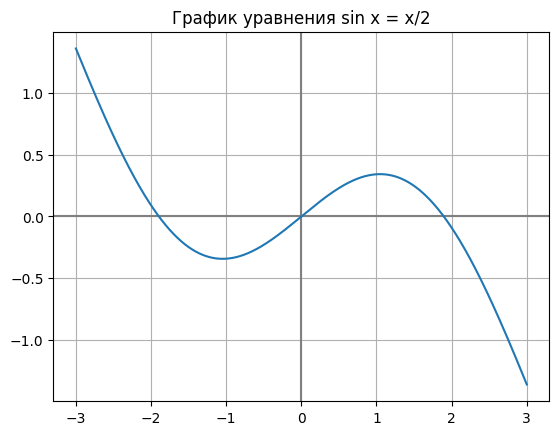

Корень: -1.895528098455192, Начальное приближение: -2
|φ'(x)| > 1, невозможно точно найти ноль
Корень: 1.895528098455192, Начальное приближение: +2


In [16]:
def f(x):
    return np.sin(x) - x/2


x = np.linspace(-3, 3, 1000)
y = f(x)

plt.grid()
plt.axvline(x=0, color="gray")
plt.axhline(y=0, color="gray")

plt.plot(x, y)
plt.title('График уравнения sin x = x/2')
plt.show()

# print("\nМетод дихотомии:")
# intervals = [(-2, -1), (-0.5, 0.5), (1, 2)]


# for a, b in intervals:
#     root, count = dihotomy(a, b, sys.float_info.epsilon)
#     print(f"Корень: {root:+.10f}, Отрезок: [{a:+}, {b:+}] ({count} итераций)")


# print("\nМетод Ньютона:")
    
approximate_points = [-2, 0.5, 2]
# for x0 in approximate_points:
#     root, count = newton(x0)
#     print(f"Корень: {root:+.10f}, Начальное приближение: {x0:+} ({count} итераций)")


def sin_simple_iteration(x0, epsilon):
    if x0 == 0:
        return 0.0
    x_prev = x0
    while True:
        x = 2 * np.sin(x_prev)
        if abs(x - x_prev) < epsilon:
            return x
        x_prev = x

eps = 0.0001
for point in approximate_points:
    if abs(2*np.cos(point)) > 1:
        print("|φ'(x)| > 1, невозможно точно найти ноль")
    else:
        print(f"Корень: {sin_simple_iteration(point, eps)}, Начальное приближение: {point:+}")
